In [6]:
from google.colab import drive
drive.mount('/content/drive')

data_dir = "/content/drive/MyDrive/Colab Notebooks/dataset"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    data_dir + "/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    data_dir + "/validation",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 1800 images belonging to 6 classes.
Found 300 images belonging to 6 classes.


In [10]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 818s 14s/step - accuracy: 0.6339 - loss: 1.0245 - val_accuracy: 0.8567 - val_loss: 0.4569
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.8444 - loss: 0.5099 - val_accuracy: 0.8900 - val_loss: 0.3716
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.8489 - loss: 0.4286 - val_accuracy: 0.8833 - val_loss: 0.3600
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.8944 - loss: 0.3408 - val_accuracy: 0.8900 - val_loss: 0.3159
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.9056 - loss: 0.2832 - val_accuracy: 0.8933 - val_loss: 0.3422
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.9033 - loss: 0.2705 - val_accuracy: 0.8900 - val_loss: 0.3283
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.9167 - loss: 0.2543 - val_accuracy: 0.8900 - val_loss: 0.3173
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.9261 - loss: 0.2267 - val_accuracy: 0.9000 - 

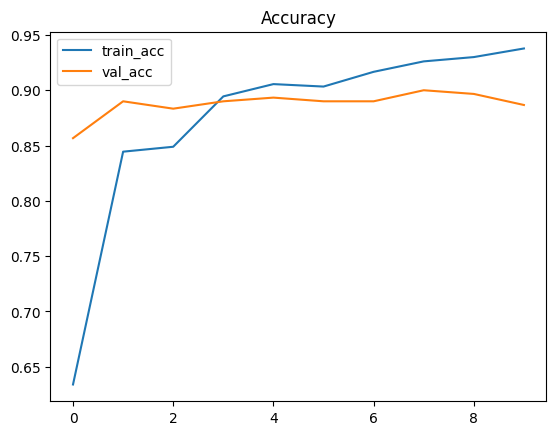

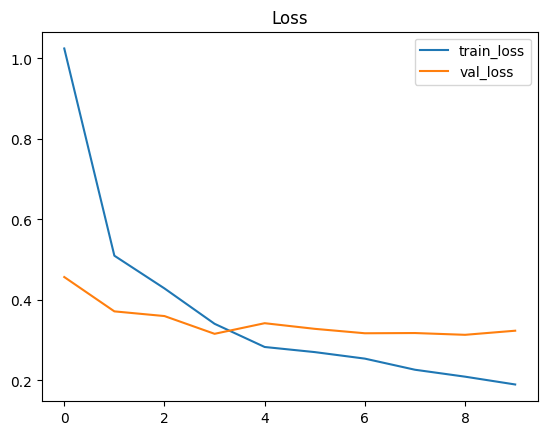

In [14]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

In [15]:
test_data = val_datagen.flow_from_directory(
    data_dir + "/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

Found 300 images belonging to 6 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 90s 9s/step - accuracy: 0.9133 - loss: 0.2413
Test Accuracy: 0.9133333563804626


In [16]:
model.save("street_food_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


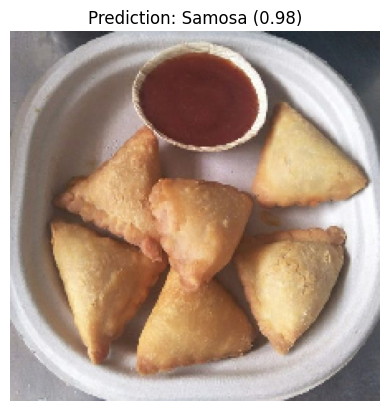

In [20]:
from tensorflow.keras.preprocessing import image
import numpy as np

class_names = ['Vada Pav', 'Paani Puri', 'Masala Dosa', 'Idli', 'Samosa', 'Grilled Sandwich']

# Load image
img_path = '/content/drive/MyDrive/Colab Notebooks/dataset/test/Samosa/0c40486ab05b874748e7902cece414fd.jpg'  # change image path
img = image.load_img(img_path, target_size=(224, 224))

# Preprocess
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediction
# The model was saved as 'street_food_model.h5', so we need to load it first.
# Assuming the model is loaded as 'model' or 'loaded_model'.
# If 'street_food_model.h5' was intended to be the loaded model object, it needs to be loaded properly.
# For now, I'll assume 'model' refers to the trained model object from previous cells.
# If a new model needs to be loaded from 'street_food_model.h5', the line should be:
# from tensorflow.keras.models import load_model
# street_food_model = load_model('street_food_model.h5')

pred = model.predict(img_array)
pred_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

# Show result
plt.imshow(img)
plt.title(f"Prediction: {pred_class} ({confidence:.2f})")
plt.axis('off')
plt.show()

In [ ]:
base = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = tf.keras.layers.Flatten()(base.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)
output = tf.keras.layers.Dense(train_data.num_classes, activation='softmax')(x)

model_vgg = tf.keras.Model(inputs=base.input, outputs=output)
model_vgg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_vgg = model_vgg.fit(train_data, validation_data=val_data, epochs=10)

Epoch 1/10
 8/57 ━━━━━━━━━━━━━━━━━━━━ 49:38 61s/step - accuracy: 0.1362 - loss: 8.4350